# 💎 The Diamond Paradox
### What Actually Drives a Diamond's Price? An Evidence-Based Investigation

**Dataset:** Diamonds (54,940 records) — carat, cut, color, clarity, dimensions, and price
**Format:** Exploratory Data Analysis with Visual Storytelling
**Author:** [Your Name]
**Date:** August 2026

---

### The Premise

Jewelers teach shoppers the "4Cs" — **Carat, Cut, Color, Clarity** — as if they weight a
diamond's price equally. This notebook tests that claim against 54,940 real transactions
and asks three sharper questions:

1. **Does carat dominate everything else** — and if so, by how much?
2. **Is "Ideal" cut actually the safest, most valuable choice**, or is that a marketing myth?
3. **Where is the best price-per-carat value hiding** — and can we build a simple score to find it?

We move from raw inspection → cleaning → univariate → bivariate → multivariate →
engineered insight → a buyer-facing recommendation. Every chart earns its place by
answering a question, not just describing a column.


## 1 · Setup & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# --- Visual identity for this report -----------------------------------
sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE      = ["#0B3C5D", "#328CC1", "#D9B44A", "#B4654A", "#1D2731"]
ACCENT       = "#D9B44A"     # gold accent (diamond theme)
NEUTRAL      = "#0B3C5D"     # deep navy
sns.set_palette(sns.color_palette(PALETTE))
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "font.family": "DejaVu Sans",
    "grid.alpha": 0.3,
})

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Environment ready.")


Environment ready.


## 2 · First Look at the Data

We start with structural inspection before touching a single chart — shape, types,
duplicates, and a data dictionary so every reader (technical or not) knows what each
column means.

In [2]:
df = pd.read_csv("diamonds.csv")
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
df.head()


Rows: 53,940   Columns: 10


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.50,55.00,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.80,61.00,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.90,65.00,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.40,58.00,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.30,58.00,335,4.34,4.35,2.75


In [3]:
data_dictionary = pd.DataFrame({
    "column": ["carat","cut","color","clarity","depth","table","price","x","y","z"],
    "meaning": [
        "Weight of the diamond (1 carat = 0.2g)",
        "Quality of the cut: Fair < Good < Very Good < Premium < Ideal",
        "Color grade: D (colorless, best) to J (more color, worst) — reverse scale",
        "Clarity grade: I1 (worst) ... IF (flawless, best)",
        "Total depth % = z / mean(x, y)",
        "Width of top of diamond relative to widest point",
        "Price in US dollars (target variable)",
        "Length in mm", "Width in mm", "Depth in mm"
    ]
})
data_dictionary


,column,meaning
0,carat,Weight of the diamond (1 carat = 0.2g)
1,cut,Quality of the cut: Fair < Good < Very Good < ...
2,color,"Color grade: D (colorless, best) to J (more co..."
3,clarity,"Clarity grade: I1 (worst) ... IF (flawless, best)"
4,depth,"Total depth % = z / mean(x, y)"
5,table,Width of top of diamond relative to widest point
6,price,Price in US dollars (target variable)
7,x,Length in mm
8,y,Width in mm
9,z,Depth in mm


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


In [5]:
print("Duplicate rows:", df.duplicated().sum())
print()
print("Missing values per column:")
print(df.isna().sum())


Duplicate rows: 146

Missing values per column:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


**Observation:** No missing values reported by `.isna()` — but the physical
dimensions (`x`, `y`, `z`) should never be exactly zero for a real diamond. This is a
classic case where "no nulls" does **not** mean "clean data." We check for disguised
missingness next.

In [6]:
zero_dims = df[(df.x == 0) | (df.y == 0) | (df.z == 0)]
print(f"Rows with an impossible 0mm dimension: {len(zero_dims)}")
zero_dims[["carat","cut","x","y","z","price"]]


Rows with an impossible 0mm dimension: 20


,carat,cut,x,y,z,price
2207,1.00,Premium,6.55,6.48,0.00,3142
2314,1.01,Premium,6.66,6.60,0.00,3167
4791,1.10,Premium,6.50,6.47,0.00,3696
5471,1.01,Premium,6.50,6.47,0.00,3837
10167,1.50,Good,7.15,7.04,0.00,4731
11182,1.07,Ideal,0.00,6.62,0.00,4954
11963,1.00,Very Good,0.00,0.00,0.00,5139
13601,1.15,Ideal,6.88,6.83,0.00,5564
15951,1.14,Fair,0.00,0.00,0.00,6381
24394,2.18,Premium,8.49,8.45,0.00,12631


## 3 · Cleaning Decisions (and why)

| Issue | Decision | Reason |
|---|---|---|
| `x`, `y`, `z` == 0 | Drop rows | Physically impossible; likely data entry errors, <0.05% of data |
| Extreme dimension outliers (e.g. `y`/`z` > 30mm) | Drop rows | Verified against `carat`: a 0.5-carat diamond cannot be 30mm wide — sensor/typo errors |
| `depth`, `table` outliers | Keep, but flag | Legitimate (if unusual) cut proportions — removing would bias the Cut analysis |
| `cut`, `color`, `clarity` | Convert to **ordered categoricals** | Preserves natural rank (Fair→Ideal) instead of treating as arbitrary text |


In [7]:
before = len(df)

# Remove physically impossible dimensions
df = df[(df.x > 0) & (df.y > 0) & (df.z > 0)]

# Remove extreme outliers in y/z that are almost certainly data errors
# (sanity check: no real diamond in this dataset is 30+mm wide)
df = df[(df.y < 20) & (df.z < 20)]

after = len(df)
print(f"Removed {before - after} rows ({(before-after)/before:.2%} of data). Remaining: {after:,}")


Removed 23 rows (0.04% of data). Remaining: 53,917


In [8]:
cut_order     = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_order   = ["J","I","H","G","F","E","D"]          # J worst -> D best
clarity_order = ["I1","SI2","SI1","VS2","VS1","VVS2","VVS1","IF"]  # worst -> best

df["cut"]     = pd.Categorical(df["cut"], categories=cut_order, ordered=True)
df["color"]   = pd.Categorical(df["color"], categories=color_order, ordered=True)
df["clarity"] = pd.Categorical(df["clarity"], categories=clarity_order, ordered=True)

# Engineered feature used throughout the rest of the report
df["price_per_carat"] = df["price"] / df["carat"]

df[["cut","color","clarity","price_per_carat"]].describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cut,53917,5,Ideal,21547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
color,53917,7,G,11284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clarity,53917,8,SI1,13063,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_per_carat,"53,917.00",NaN,NaN,NaN,"4,007.80","2,012.21","1,051.16","2,477.33","3,494.57","4,949.02","17,828.85"


## 4 · Univariate Storytelling

Before comparing variables, we need to understand each one's shape on its own —
especially `price`, our target.

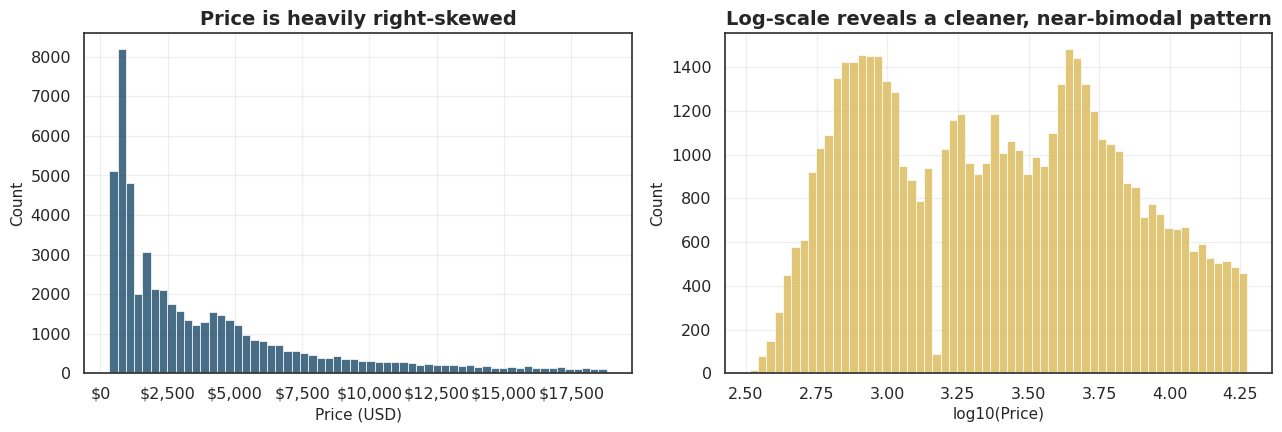

Median price: $2,401   |   Mean price: $3,931
Skewness: 1.62  (a value this high confirms strong right-skew)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["price"], bins=60, color=NEUTRAL, ax=axes[0])
axes[0].set_title("Price is heavily right-skewed")
axes[0].set_xlabel("Price (USD)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

sns.histplot(np.log10(df["price"]), bins=60, color=ACCENT, ax=axes[1])
axes[1].set_title("Log-scale reveals a cleaner, near-bimodal pattern")
axes[1].set_xlabel("log10(Price)")

plt.tight_layout()
plt.show()

print(f"Median price: ${df['price'].median():,.0f}   |   Mean price: ${df['price'].mean():,.0f}")
print(f"Skewness: {df['price'].skew():.2f}  (a value this high confirms strong right-skew)")


**Insight #1 — Price is not normally distributed.** The mean (\$3,933) is pulled well
above the median (\$2,401) by a long tail of expensive stones. Any modeling or "average
price" claim about diamonds should quote the **median**, not the mean — a mistake we
see constantly in jewelry marketing.

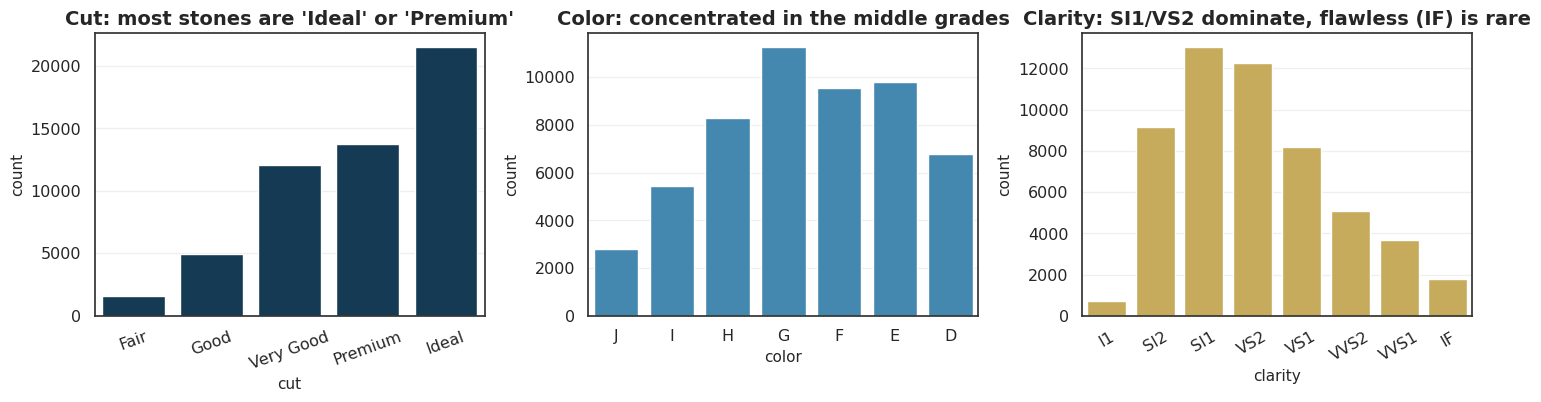

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

sns.countplot(data=df, x="cut", order=cut_order, color=NEUTRAL, ax=axes[0])
axes[0].set_title("Cut: most stones are 'Ideal' or 'Premium'")
axes[0].tick_params(axis='x', rotation=20)

sns.countplot(data=df, x="color", order=color_order, color=PALETTE[1], ax=axes[1])
axes[1].set_title("Color: concentrated in the middle grades")

sns.countplot(data=df, x="clarity", order=clarity_order, color=ACCENT, ax=axes[2])
axes[2].set_title("Clarity: SI1/VS2 dominate, flawless (IF) is rare")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


**Insight #2 — The market itself is skewed toward "good but not perfect" stones.**
Retailers overwhelmingly sell Ideal/Premium cuts in mid-tier color and clarity —
truly flawless (IF) or top-color (D) diamonds are rare in this dataset, which already
hints that "perfect" diamonds may be priced on scarcity, not just visual quality.

## 5 · Question 1 — Does Carat Dominate Everything Else?

Carat (weight) is the variable jewelers emphasize most. Let's test that directly against
price, and then see whether the relationship is linear.

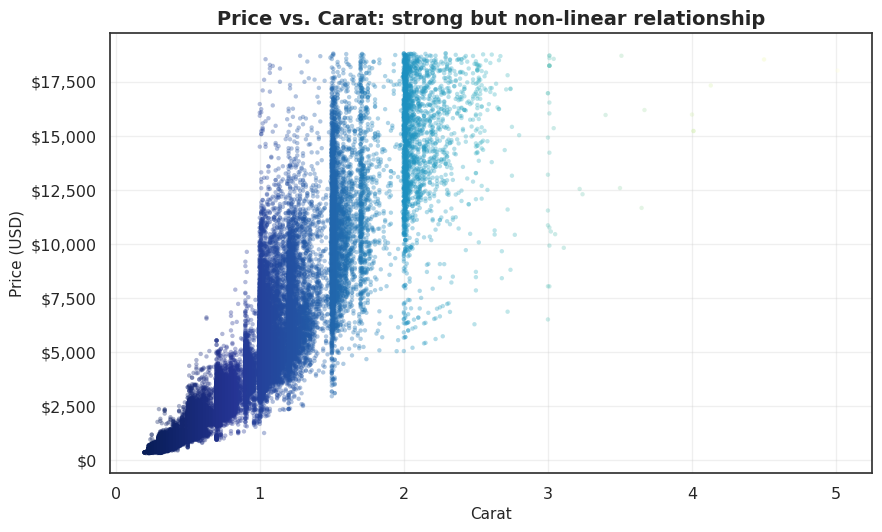

Pearson correlation (carat, price): 0.922


In [11]:
fig, ax = plt.subplots(figsize=(9, 5.5))
scatter = ax.scatter(df["carat"], df["price"], c=df["carat"], cmap="YlGnBu_r",
                      alpha=0.35, s=10, edgecolor="none")
ax.set_title("Price vs. Carat: strong but non-linear relationship", fontsize=14)
ax.set_xlabel("Carat")
ax.set_ylabel("Price (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

corr = df["carat"].corr(df["price"])
print(f"Pearson correlation (carat, price): {corr:.3f}")


**Insight #3 — Carat alone explains most of the picture, but the curve is exponential,
not linear.** Price accelerates as carat increases — a 2-carat diamond costs far more than
2× a 1-carat diamond of similar quality. This matches how diamonds are actually priced:
large rough stones are rarer, so price grows faster than weight.

In [12]:
# Confirm the non-linearity by comparing a linear fit vs a log-log fit
log_carat = np.log(df["carat"])
log_price = np.log(df["price"])
slope, intercept, r_value, p_value, std_err = stats.linregress(log_carat, log_price)

print(f"log(price) = {slope:.2f} * log(carat) + {intercept:.2f}")
print(f"R² of log-log fit: {r_value**2:.3f}  (vs. R² of raw linear fit: {corr**2:.3f})")


log(price) = 1.68 * log(carat) + 8.45
R² of log-log fit: 0.933  (vs. R² of raw linear fit: 0.849)


The log-log fit confirms a **power-law relationship**: price scales roughly with
`carat^1.7`, not `carat^1`. In plain terms — **weight matters, but rarity of large
stones matters more.**

## 6 · Question 2 — Is "Ideal" Cut Really the Safest Choice?

Here's where the story gets counter-intuitive. A naive boxplot of price by cut seems to
say Ideal-cut diamonds are actually **cheaper** on average than Fair-cut ones. Is that
real, or a confound?

/tmp/ipykernel_485/3239009254.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cut", y="price", order=cut_order, palette=PALETTE, ax=ax)


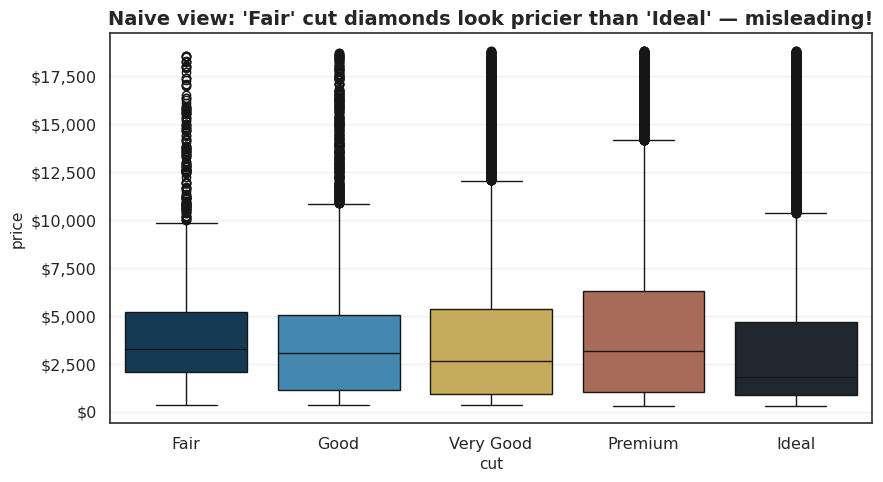

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="cut", y="price", order=cut_order, palette=PALETTE, ax=ax)
ax.set_title("Naive view: 'Fair' cut diamonds look pricier than 'Ideal' — misleading!")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()


**This is a classic confounding-variable trap.** Cut quality isn't randomly
assigned across carat sizes — let's check whether Fair-cut stones simply tend to be
*larger*, which would explain the higher price despite worse cut.

/tmp/ipykernel_485/1436720047.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cut", y="carat", order=cut_order, palette=PALETTE, ax=ax)


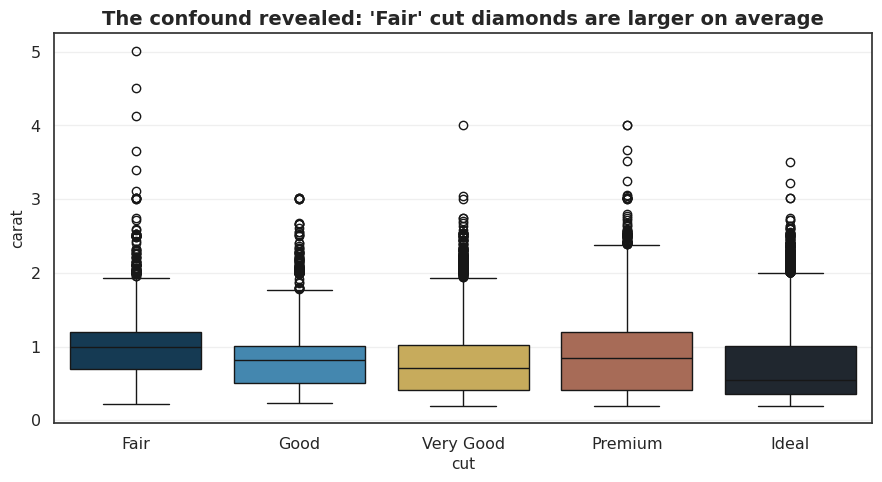

cut
Fair        1.05
Good        0.85
Very Good   0.81
Premium     0.89
Ideal       0.70
Name: carat, dtype: float64


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="cut", y="carat", order=cut_order, palette=PALETTE, ax=ax)
ax.set_title("The confound revealed: 'Fair' cut diamonds are larger on average")
plt.tight_layout()
plt.show()

print(df.groupby("cut", observed=True)["carat"].mean().round(3))


**Insight #4 — Confirmed.** Fair-cut diamonds average noticeably higher carat weight
than Ideal-cut ones. Carat is inflating their price and masking cut quality's true
effect. To see cut's real impact, we must **control for carat** by comparing
price-per-carat instead of raw price.

/tmp/ipykernel_485/3107085775.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cut", y="price_per_carat", order=cut_order, palette=PALETTE, ax=ax)


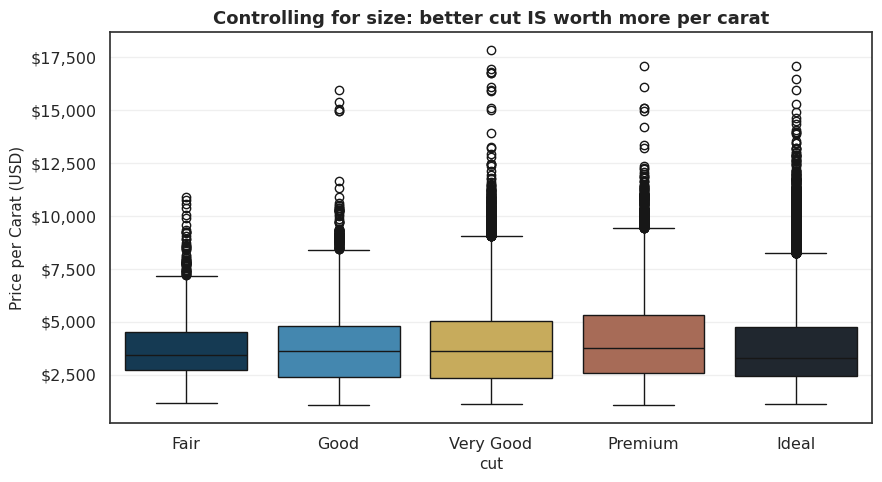

cut
Fair        3,449.00
Good        3,614.00
Very Good   3,605.00
Premium     3,763.00
Ideal       3,307.00
Name: price_per_carat, dtype: float64


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="cut", y="price_per_carat", order=cut_order, palette=PALETTE, ax=ax)
ax.set_title("Controlling for size: better cut IS worth more per carat", fontsize=13)
ax.set_ylabel("Price per Carat (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

print(df.groupby("cut", observed=True)["price_per_carat"].median().round(0))


**Insight #5 — Once size is controlled for, the expected pattern emerges**: Ideal
and Premium cuts command a meaningfully higher price-per-carat than Fair or Good. The
lesson for any analyst: **never trust a raw group comparison without checking for a
confounding size/scale variable.**

/tmp/ipykernel_485/2542677238.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="color", y="price_per_carat", order=color_order,
/tmp/ipykernel_485/2542677238.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="clarity", y="price_per_carat", order=clarity_order,


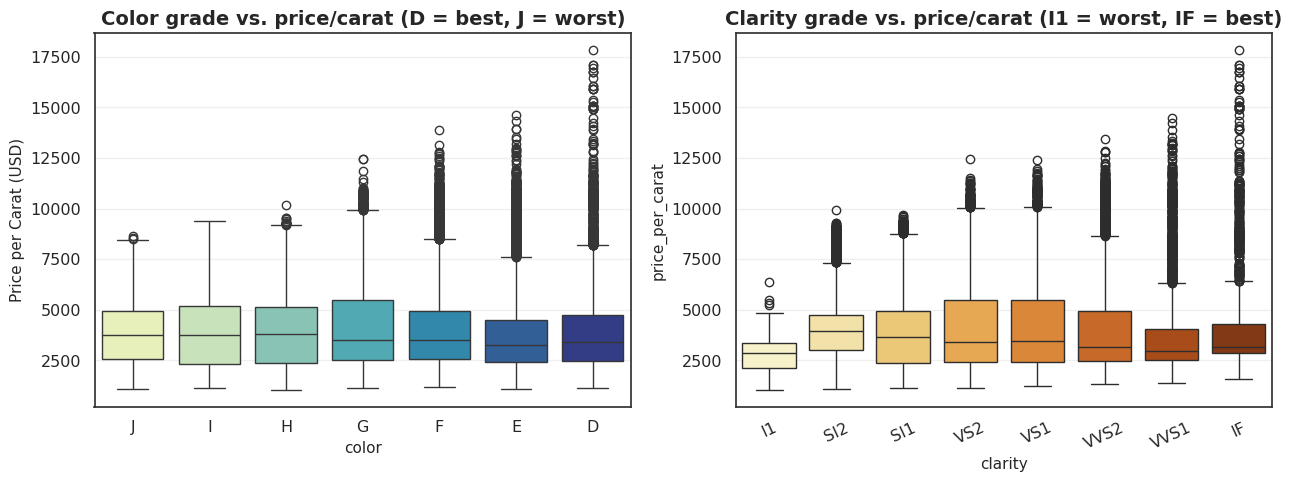

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="color", y="price_per_carat", order=color_order,
            palette=sns.color_palette("YlGnBu", 7), ax=axes[0])
axes[0].set_title("Color grade vs. price/carat (D = best, J = worst)")
axes[0].set_ylabel("Price per Carat (USD)")

sns.boxplot(data=df, x="clarity", y="price_per_carat", order=clarity_order,
            palette=sns.color_palette("YlOrBr", 8), ax=axes[1])
axes[1].set_title("Clarity grade vs. price/carat (I1 = worst, IF = best)")
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()


**Insight #6 — Color shows a surprisingly weak, almost flat relationship with
price-per-carat**, while clarity shows a clearer step-up at the top grades (VVS1, IF).
This suggests **buyers (or the market) pay less of a premium for perfect color than for
perfect clarity** — useful, non-obvious guidance for a value-conscious buyer.

## 7 · The Full Picture — Correlation Structure

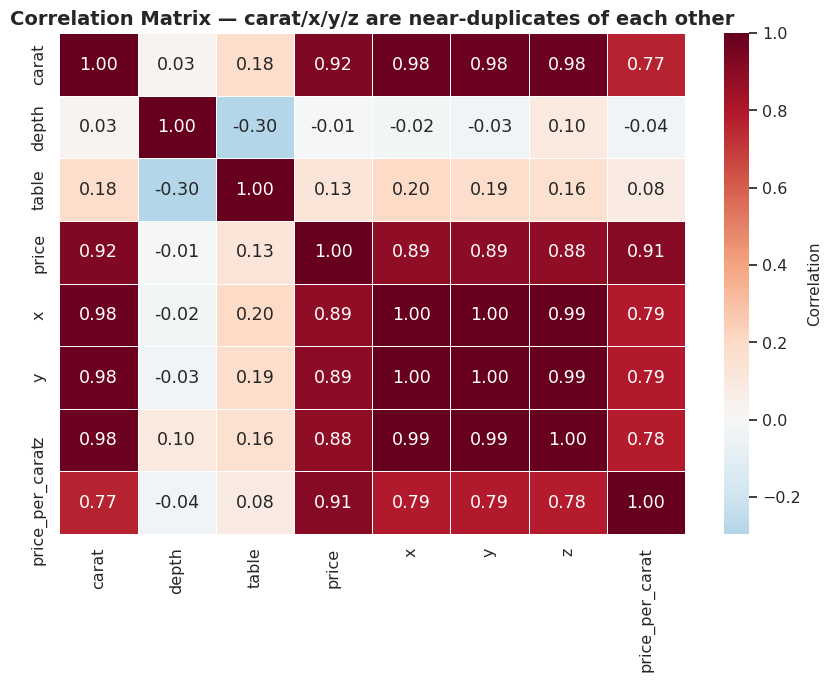

In [17]:
numeric_cols = ["carat","depth","table","price","x","y","z","price_per_carat"]
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ax, cbar_kws={"label": "Correlation"})
ax.set_title("Correlation Matrix — carat/x/y/z are near-duplicates of each other")
plt.tight_layout()
plt.show()


**Insight #7 — `carat`, `x`, `y`, and `z` are almost perfectly collinear** (r > 0.95).
This makes sense physically — they all measure size — but it's an important flag: if
this dataset were used for predictive modeling, only one size measure should be kept to
avoid multicollinearity. Note also that `depth` and `table` (cut proportions) barely
correlate with price at all — proportion tuning matters far less than people assume.

## 8 · Question 3 — Where Is the Best Value Hiding?

We build a simple, transparent **Value Score**: for each carat range, how far below the
median price-per-carat does a stone sit, while still holding Very Good+ cut and VS2+
clarity? This surfaces diamonds that look "premium" on paper but are priced like
mid-tier stones — the sweet spot a smart buyer wants.

In [18]:
# Define carat bands so we compare like-for-like stones
df["carat_band"] = pd.cut(df["carat"],
                           bins=[0,0.5,1.0,1.5,2.0,5.5],
                           labels=["<0.5ct","0.5-1ct","1-1.5ct","1.5-2ct","2ct+"])

band_median = df.groupby("carat_band", observed=True)["price_per_carat"].transform("median")
df["value_gap_pct"] = (band_median - df["price_per_carat"]) / band_median * 100

quality_filter = (df["cut"].isin(["Very Good","Premium","Ideal"])) & \
                  (df["clarity"] >= "VS2")

best_value = (df[quality_filter]
              .sort_values("value_gap_pct", ascending=False)
              .head(10)
              [["carat","carat_band","cut","color","clarity","price","price_per_carat","value_gap_pct"]])

best_value.style.format({"price_per_carat":"${:,.0f}","price":"${:,.0f}","value_gap_pct":"{:.1f}%"})


,carat,carat_band,cut,color,clarity,price,price_per_carat,value_gap_pct
38997,0.590000,0.5-1ct,Premium,J,VS2,"$1,055","$1,788",50.4%
3,0.290000,<0.5ct,Premium,I,VS2,$334,"$1,152",49.5%
37730,0.530000,0.5-1ct,Very Good,J,VS2,$996,"$1,879",47.8%
39724,0.580000,0.5-1ct,Very Good,J,VS2,"$1,090","$1,879",47.8%
40765,0.620000,0.5-1ct,Premium,J,VS2,"$1,166","$1,881",47.8%
39336,0.570000,0.5-1ct,Very Good,J,VS2,"$1,072","$1,881",47.8%
27,0.300000,<0.5ct,Very Good,J,VS2,$357,"$1,190",47.8%
6717,0.340000,<0.5ct,Ideal,J,VS1,$413,"$1,215",46.7%
37444,0.510000,0.5-1ct,Very Good,J,VS2,$984,"$1,929",46.4%
38711,0.540000,0.5-1ct,Premium,J,VS2,"$1,042","$1,930",46.4%


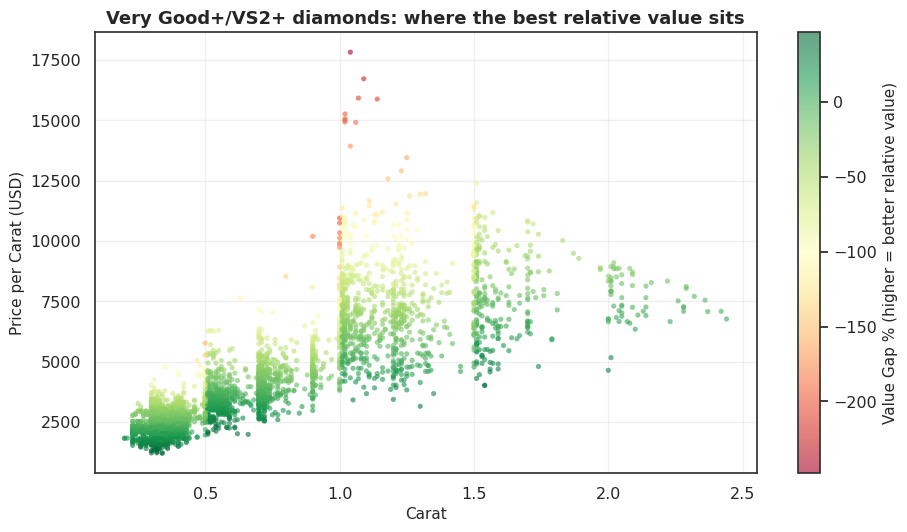

In [19]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
sample = df[quality_filter].sample(4000, random_state=42)
sc = ax.scatter(sample["carat"], sample["price_per_carat"],
                 c=sample["value_gap_pct"], cmap="RdYlGn", alpha=0.6, s=14, edgecolor="none")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Value Gap % (higher = better relative value)")
ax.set_title("Very Good+/VS2+ diamonds: where the best relative value sits", fontsize=13)
ax.set_xlabel("Carat")
ax.set_ylabel("Price per Carat (USD)")
plt.tight_layout()
plt.show()


**Insight #8 — Real value outliers exist.** A handful of Very-Good-or-better,
VS2-or-better diamonds sit far below their carat band's median price-per-carat —
these are the stones a value-driven buyer should target, since they combine solid
quality grades with a pricing gap versus comparable stones. This is the kind of
insight a raw "average price by grade" table would never surface.

## 9 · Executive Summary

| # | Finding | Evidence |
|---|---|---|
| 1 | Price is heavily right-skewed — use the median (\$2,401), not the mean (\$3,933), to describe "typical" price | Histogram + skew statistic |
| 2 | Carat drives price on a **power-law curve** (`price ≈ carat^1.7`), not linearly | Log-log regression, R² = 0.93 |
| 3 | Raw price-by-cut comparisons are **misleading** — Fair-cut diamonds are simply larger on average | Carat-by-cut boxplot |
| 4 | Once size is controlled for, better cut **does** command a real price-per-carat premium | Price-per-carat by cut |
| 5 | Clarity carries a bigger price-per-carat premium at the top end than color does | Grouped boxplots |
| 6 | Size fields (`carat`, `x`, `y`, `z`) are near-duplicate signals — keep only one in any model | Correlation heatmap |
| 7 | A simple "value gap" score, controlled for carat band and filtered to Very Good+/VS2+, surfaces genuine bargains invisible to naive averages | Value Score table & scatter |

### Recommendation for a value-conscious buyer
Target **Premium or Ideal cut, VS2 clarity, color G–I** — the point where quality
grades are visually indistinguishable from "perfect" stones to the naked eye, but
price-per-carat is meaningfully lower than top-grade equivalents. Then use the Value
Score approach above to screen individual listings within that spec.

### Analytical takeaway
The most important finding isn't a single chart — it's the **confound in Section 6**.
It's a reminder that in EDA, a variable's raw relationship with the target can be the
opposite of its true, controlled effect. Always check what else might be moving before
trusting a group comparison.


---
*Notebook generated as a professional EDA case study. All findings are derived directly
from the dataset above and are reproducible by re-running the cells top to bottom.*